In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


In [2]:
import zipfile
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("casting_data_extracted")
print("Done unzipping")

Done unzipping


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

In [4]:
DATA_ROOT = "casting_data_extracted/casting_data/casting_data"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_NAMES = ["ok_front", "def_front"]

train_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, "train"),
    class_names=CLASS_NAMES,
    validation_split=0.20,
    subset="training",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, "train"),
    class_names=CLASS_NAMES,
    validation_split=0.20,
    subset="validation",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, "test"),
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

Found 6633 files belonging to 2 classes.
Using 5307 files for training.
Found 6633 files belonging to 2 classes.
Using 1326 files for validation.
Found 715 files belonging to 2 classes.


In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
])

In [6]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1.0 / 255),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.40),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

In [8]:
os.makedirs("models", exist_ok=True)
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint(filepath="models/casting_cnn_documented.keras", monitor="val_loss", save_best_only=True)
]

In [9]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - accuracy: 0.5581 - loss: 0.6881 - precision: 0.5603 - recall: 0.9845 - val_accuracy: 0.5897 - val_loss: 0.6782 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.5608 - loss: 0.6858 - precision: 0.5608 - recall: 1.0000 - val_accuracy: 0.5897 - val_loss: 0.6780 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.5613 - loss: 0.6808 - precision: 0.5612 - recall: 0.9990 - val_accuracy: 0.5897 - val_loss: 0.6627 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.6241 - loss: 0.6477 - precision: 0.6151 - recall: 0.8807 - val_accuracy: 0.6312 - val_loss: 0.6580 - val_precision: 0.7479 - val_recall: 0.5652 - learning_rate: 0.0010
Epoch 5/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - 

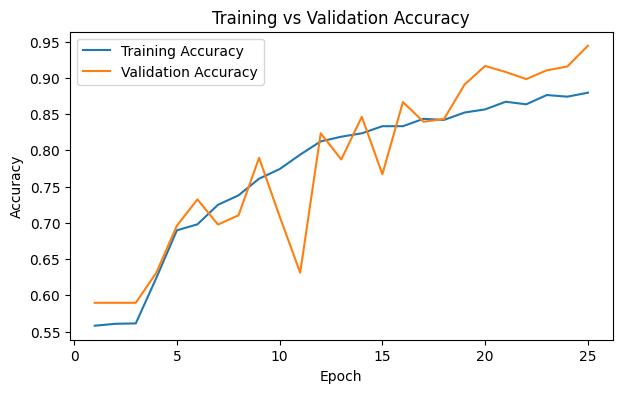

In [10]:
os.makedirs("reports", exist_ok=True)
epochs_range = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, history.history["accuracy"], label="Training Accuracy")
plt.plot(epochs_range, history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.savefig("reports/accuracy_graph.png", dpi=150, bbox_inches="tight")
plt.show()

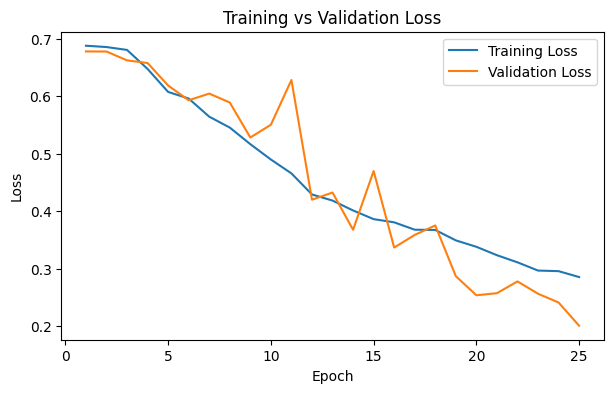

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(epochs_range, history.history["loss"], label="Training Loss")
plt.plot(epochs_range, history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.savefig("reports/loss_graph.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
test_results = model.evaluate(test_dataset)
print("Loss, Accuracy, Precision, Recall:", test_results)

probabilities = model.predict(test_dataset)
predictions = (probabilities.flatten() >= 0.5).astype(int)
actual_labels = np.concatenate([labels.numpy().flatten() for _, labels in test_dataset]).astype(int)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9497 - loss: 0.1897 - precision: 0.9664 - recall: 0.9536
Loss, Accuracy, Precision, Recall: [0.1897442638874054, 0.9496503472328186, 0.9664429426193237, 0.9536423683166504]
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


[[247  15]
 [ 21 432]]
TN=247  FP=15  FN=21  TP=432


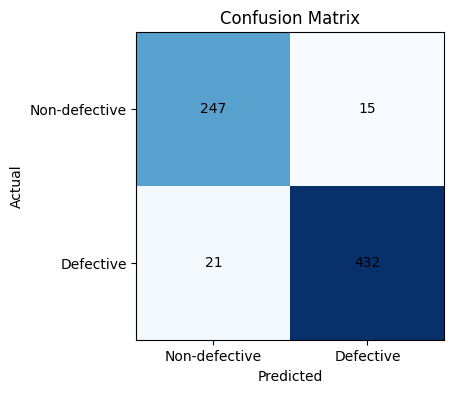

In [13]:
matrix = confusion_matrix(actual_labels, predictions)
print(matrix)
tn, fp, fn, tp = matrix.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

plt.figure(figsize=(4.5, 4))
plt.imshow(matrix, cmap="Blues")
plt.xticks([0, 1], ["Non-defective", "Defective"])
plt.yticks([0, 1], ["Non-defective", "Defective"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, matrix[i, j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("reports/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
def predict_image(image_path, threshold=0.5):
    image = tf.keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
    array = tf.expand_dims(tf.keras.utils.img_to_array(image), axis=0)
    probability = float(model.predict(array, verbose=0)[0][0])
    label = "Defective" if probability >= threshold else "Non-defective"
    action = "Send for manual inspection" if probability >= threshold else "Proceed"
    print(f"{image_path}\n  Prediction: {label}  |  Probability: {probability:.1%}  |  Action: {action}\n")

ok_dir = os.path.join(DATA_ROOT, "test", "ok_front")
def_dir = os.path.join(DATA_ROOT, "test", "def_front")
sample_paths = [os.path.join(ok_dir, f) for f in os.listdir(ok_dir)[:3]] + [os.path.join(def_dir, f) for f in os.listdir(def_dir)[:2]]

for path in sample_paths:
    predict_image(path)

casting_data_extracted/casting_data/casting_data/test/ok_front/cast_ok_0_2758.jpeg
  Prediction: Non-defective  |  Probability: 12.8%  |  Action: Proceed

casting_data_extracted/casting_data/casting_data/test/ok_front/cast_ok_0_2784.jpeg
  Prediction: Non-defective  |  Probability: 12.0%  |  Action: Proceed

casting_data_extracted/casting_data/casting_data/test/ok_front/cast_ok_0_2844.jpeg
  Prediction: Non-defective  |  Probability: 1.2%  |  Action: Proceed

casting_data_extracted/casting_data/casting_data/test/def_front/cast_def_0_1681.jpeg
  Prediction: Defective  |  Probability: 92.9%  |  Action: Send for manual inspection

casting_data_extracted/casting_data/casting_data/test/def_front/cast_def_0_1379.jpeg
  Prediction: Defective  |  Probability: 87.4%  |  Action: Send for manual inspection



In [15]:
model_v2 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1.0 / 255),
    layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"), layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.20),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_v2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
history_v2 = model_v2.fit(train_dataset, validation_data=validation_dataset, epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)])
test_results_v2 = model_v2.evaluate(test_dataset)
print("Dropout 0.20 test results:", test_results_v2)

Epoch 1/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.5574 - loss: 0.6887 - val_accuracy: 0.5897 - val_loss: 0.6794
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.5608 - loss: 0.6866 - val_accuracy: 0.5897 - val_loss: 0.6776
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.5634 - loss: 0.6831 - val_accuracy: 0.5897 - val_loss: 0.6580
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.5985 - loss: 0.6565 - val_accuracy: 0.5897 - val_loss: 0.6642
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.6832 - loss: 0.5909 - val_accuracy: 0.7934 - val_loss: 0.5115
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.7417 - loss: 0.5350 - val_accuracy: 0.7504 - val_loss: 0.4959
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.7647 - loss: 0.5104 - val_accuracy: 0.8401 - val_loss: 0.4310
Epoch 8/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.7692 - loss: 0.5024 - v